# MCMC for hierarchical Bayesian models

**Day 3, 11:00 — 60 minutes.** Alexander Fengler (with Brandon Turner).

The motivating slides are
[here](hierarchical-mcmc-slides.qmd). This notebook is the hands-on half.

Yesterday afternoon we saw posteriors that were hard because they were
**correlated** — a long thin ridge, but the same shape everywhere. Hierarchical
models bring a nastier relative: **curvature that changes as you move**. No
single step size works everywhere, and the failure is not slowness. It is
*bias*.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-hierarchy"))
rng = np.random.default_rng(RANDOM_SEED)

DRAWS, TUNE, CHAINS = 1000, 1000, 4

print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 6.2.0 | arviz 1.2.0


## 1. First: why would you want a hierarchy at all?

Most of this session is about a *problem* hierarchical models create. That
ordering is misleading unless we first establish what they buy you, so start
there.

Motivating setting: **unbalanced** data across participants. Some
participants completed hundreds of trials, some barely turned up.

In [2]:
import sbi4cogsci_figures as F      # shared with the slide deck — one source

pool = F.pooling_experiment(seed=RANDOM_SEED)
counts = pool["trial_counts"]
print(f"{counts.size} participants, {pool['n_trials_total']} trials total")
print(f"trials per participant: {counts.min()} to {counts.max()}")
print(f"  the five thinnest: {sorted(counts)[:5]}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu_v, tau_v, z_off]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


20 participants, 3081 trials total
trials per participant: 5 to 600
  the five thinnest: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]


Each participant has their own drift rate, drawn from a population. We fit the
same data twice — **no pooling** (each participant estimated alone) and
**partial pooling** (participants drawn from an estimated population) — and
compare both against the drift rates we actually used.

`a`, `z` and `t` are held at their true values so that the comparison is about
pooling and nothing else.

In [3]:
summary = F.pooling_summary(pool)
print(f"{'':18s} {'MAE (all)':>10s} {'n < 30':>10s} {'n >= 30':>10s}")
for key, label in [("no_pooling", "no pooling"), ("partial_pooling", "partial pooling")]:
    d = summary[key]
    print(f"{label:18s} {d['mae_all']:10.3f} {d['mae_low']:10.3f} {d['mae_high']:10.3f}")
print(f"\nimprovement where trials < 30: {summary['low_n_improvement_pct']:.0f}%")

                    MAE (all)     n < 30    n >= 30
no pooling              0.158      0.265      0.051
partial pooling         0.114      0.175      0.052

improvement where trials < 30: 34%


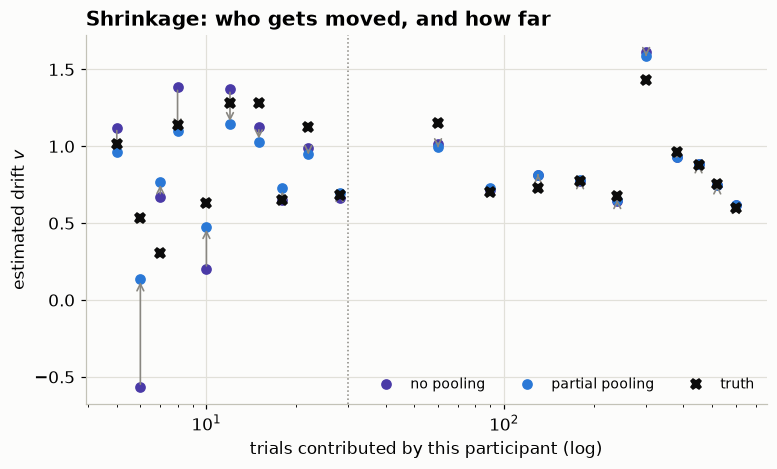

In [4]:
F.fig_shrinkage(pool)

Every arrow is one participant, running from their no-pooling estimate to
their partial-pooling one. The arrows are long on the left and invisible on
the right: **pooling moves exactly the participants who could not speak for
themselves, and leaves the others alone.**

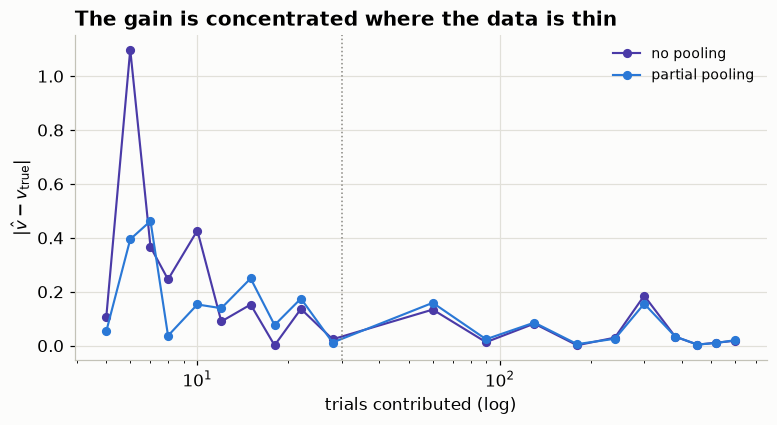

In [5]:
F.fig_pooling_error(pool)

<details class="sbi-note">
<summary>📝 <b>What pooling actually is</b></summary>

With five trials, a no-pooling estimate has almost no information to work
with, so it falls back on whatever prior you happened to write down. Partial
pooling also falls back on a prior — but on the **population**, estimated from
the participants who did have data.

**Pooling replaces an arbitrary prior with an earned one.** That is the whole
idea, and everything after this is the price you pay for it.

</details>

> **Poll.** Partial pooling improved the sparse participants a lot and the
> dense ones not at all. Why not at all?
>
> **A.** The sampler converged better for them.
>
> **B.** Their likelihood already dominates the prior, so shrinkage has
>   almost nothing to pull against.
>
> **C.** The population distribution does not apply to them.
>
> **D.** They were closer to the population mean to begin with.

<details>
<summary>Answer</summary>

**B.** Shrinkage weight is roughly $\tau^2 / (\tau^2 + \mathrm{se}_g^2)$ — it
depends on how precise *that participant's* own estimate is. With 600 trials
the standard error is tiny, the weight goes to ~1, and the estimate barely
moves. With 5 trials the standard error is large and the population wins.

Hold on to this: it is the same quantity that decides which
**parameterization** each group wants, later in this notebook.

</details>

### Did we not just add parameters?

Counted naively, partial pooling is the **bigger** model — it has everything
no-pooling has, plus $\mu$ and $\tau$. And it generalised better. Either
Occam's razor is wrong, or we are counting the wrong thing.

The right thing to count is the **effective** number of parameters, `p_loo`,
which we already computed above.

In [6]:
print(f"{'':18s} {'nominal':>9s} {'effective (p_loo)':>19s}")
for key, label in [("no_pooling", "no pooling"), ("partial_pooling", "partial pooling")]:
    print(f"{label:18s} {pool['nominal'][key]:9d} {pool['p_loo'][key]:19.1f}")

                     nominal   effective (p_loo)
no pooling                20                19.2
partial pooling           22                15.1


Two more nominal parameters; roughly **four fewer effective** ones.

A parameter costs a full unit only if the data is free to put it anywhere.
Under pooling each $v_g$ is pulled toward $\mu$, so it is no longer free — it
costs a *fraction* of a parameter. The two hyperparameters are not two extra
freedoms; they are two knobs that **remove** freedom from the other twenty,
and $\tau$ is a regularisation strength *learned from the data* rather than
guessed by you.

<details class="sbi-warn" open>
<summary>⚠️ <b>Two honest caveats before you quote this number</b></summary>

**The gap depends on how sparse your groups are.** Ours has participants with
five trials, and those shrink a lot. Re-run with 600 trials for everyone and
the gap nearly closes: each participant's own data identifies their drift,
shrinkage has nothing to pull against, and `p_loo` approaches the nominal
count. The effective-parameter story is a statement about *your data*, not
about hierarchical models in the abstract.

**`elpd_loo` was essentially a tie.** Trial-level LOO is dominated by the
participants who had plenty of trials, so it barely notices the improvement
for the sparse ones. Fewer effective parameters, same trial-level predictive
score — the benefit showed up in the **estimates**, which is what we measured
before. If you care about generalising to a *new participant*, the matching
quantity is leave-one-participant-out, not this.

</details>

<details class="sbi-note">
<summary>📝 <b>ArviZ 1.x naming</b></summary>

`az.loo(idata)` returns an object whose attribute is **`.p`**, although it
*prints* as `p_loo`. And `az.waic` no longer exists — ArviZ 1.0 removed it in
favour of PSIS-LOO. Nearly every tutorial you find online predates this.

</details>

## 2. Neal's funnel — the geometry, before any data

Neal (2003) reduced the whole problem to two lines:

$$v \sim \text{Normal}(0, 3), \qquad x_i \mid v \sim \text{Normal}\!\left(0, e^{v/2}\right)$$

There is no data and no likelihood. This is a *prior* — the shape a
hierarchical model has before the data says anything. `v` plays the role of
a log population scale, and `x` the role of group-level parameters.

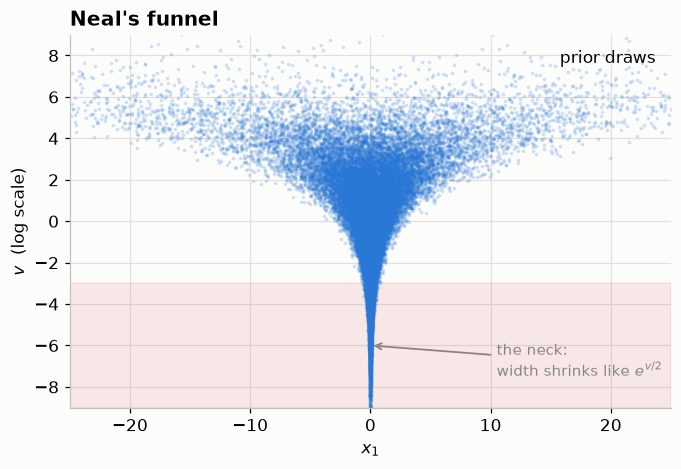

In [7]:
# Same function the slide deck bakes its copy of this figure from.
x_prior, v_prior = F.funnel_draws(n=40_000, sd_v=3.0, seed=RANDOM_SEED)
F.fig_funnel(x_prior, v_prior)

At $v = 2$ the conditional standard deviation of $x$ is $e^{1} \approx 2.7$.
At $v = -6$ it is $e^{-3} \approx 0.05$ — **fifty times narrower**. A step size
tuned for the mouth is wildly unstable in the neck; one tuned for the neck
would take forever to cross the mouth.

<details class="sbi-key" open>
<summary>🔑 <b>The failure mode is bias, not slowness</b></summary>

A sampler that cannot enter the neck does not merely explore it *slowly* — it
systematically **never goes there**, so every posterior expectation is wrong.
And $\hat{R}$ cannot see this, because all the chains fail the same way.

</details>

## 3. Sampling it, both ways

**Centered** — sample $x$ directly, with its scale depending on $v$:

$$v \sim \text{Normal}(0,3), \qquad x \sim \text{Normal}(0, e^{v/2})$$

**Non-centered** — sample a standard normal and rescale it:

$$v \sim \text{Normal}(0,3), \qquad \tilde{x} \sim \text{Normal}(0,1),
  \qquad x = e^{v/2}\,\tilde{x}$$

These describe the *same distribution*. They are different **coordinate
systems** for it, and the sampler only ever sees the coordinates.

In [8]:
def funnel_centered(dim=1):
    with pm.Model() as m:
        v = pm.Normal("v", 0.0, 3.0)
        pm.Normal("x", 0.0, pm.math.exp(v / 2), shape=dim)
    return m


def funnel_noncentered(dim=1):
    with pm.Model() as m:
        v = pm.Normal("v", 0.0, 3.0)
        x_tilde = pm.Normal("x_tilde", 0.0, 1.0, shape=dim)
        pm.Deterministic("x", pm.math.exp(v / 2) * x_tilde)
    return m


def sample(model, seed=RANDOM_SEED, **kw):
    with model:
        return pm.sample(draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
                         nuts_sampler="pymc", progressbar=False,
                         random_seed=seed, **kw)


idata_c = sample(funnel_centered())
idata_n = sample(funnel_noncentered())

for name, idata in [("centered", idata_c), ("non-centered", idata_n)]:
    div = int(idata.sample_stats["diverging"].values.sum())
    v = idata.posterior.dataset["v"].values
    print(f"{name:13s} divergences {div:5d}   "
          f"min v reached {v.min():6.2f}   mean v {v.mean():+.3f}  (true mean 0)")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


There were 276 divergences after tuning. Increase `target_accept` or reparameterize.


...

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v, x_tilde]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


centered      divergences   276   min v reached  -3.91   mean v +0.960  (true mean 0)
non-centered  divergences     0   min v reached -11.35   mean v +0.006  (true mean 0)


### The plot that shows it

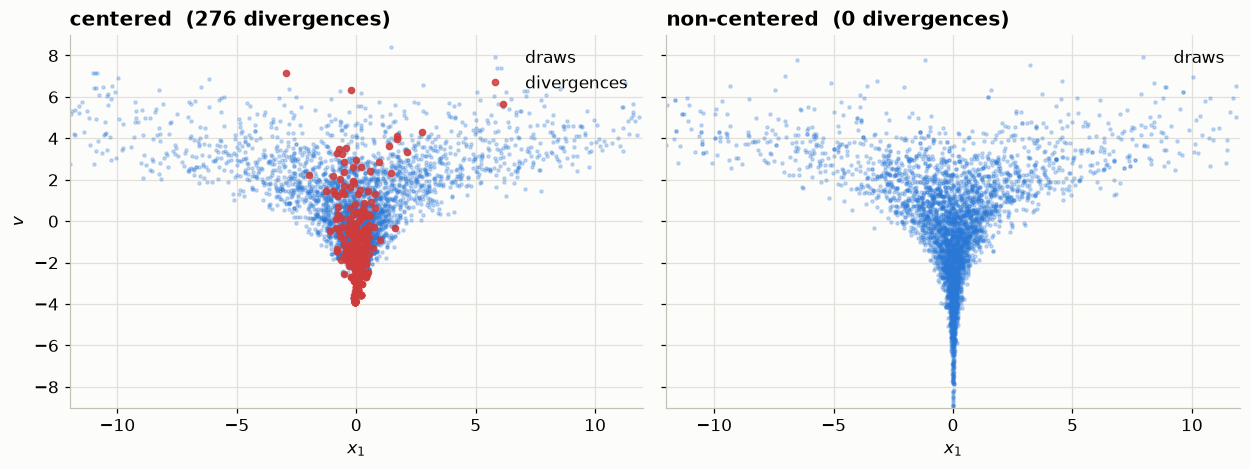

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharex=True, sharey=True)
for ax, (name, idata) in zip(axes, [("centered", idata_c), ("non-centered", idata_n)]):
    post = idata.posterior.dataset
    v = post["v"].values.ravel()
    x = post["x"].values.reshape(v.size, -1)[:, 0]
    div = idata.sample_stats["diverging"].values.ravel()
    ax.plot(x, v, "o", color=S.PRIMARY, ms=2, alpha=0.25, ls="none", label="draws")
    if div.any():
        S.divergences(ax, x[div], v[div])
    ax.set(title=f"{name}  ({int(div.sum())} divergences)",
           xlabel="$x_1$", xlim=(-12, 12), ylim=(-9, 9))
    ax.legend(loc="upper right")
axes[0].set_ylabel("$v$")
fig.tight_layout()

The divergences are not scattered at random — they **cluster in the neck**,
which is precisely the region the centered chain then under-samples.

> **Poll.** The centered run reports $\hat{R} = 1.00$ for `v`. What does that
> tell you?
>
> **A.** The chains converged; the divergences are a performance warning.
> **B.** Nothing useful — all four chains can fail in the same way.
> **C.** It means the model is correctly specified.
> **D.** It means we need more draws.

<details>
<summary>Answer</summary>

**B.** $\hat{R}$ compares chains to each other. If every chain stops at the
same place for the same geometric reason, they agree beautifully — about the
wrong answer. This is why divergences are a *separate* diagnostic and why
"$\hat{R}$ is fine" is not a clean bill of health.

</details>

### Proving it is bias

Efficiency problems shrink as you run longer. Bias does not. Track the running
mean of `v` — we know the true value is 0.

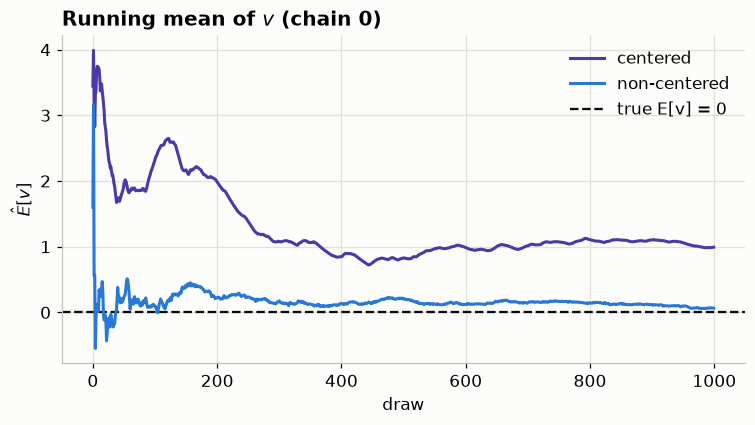

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, idata, colour in [("centered", idata_c, S.NAIVE),
                            ("non-centered", idata_n, S.PRIMARY)]:
    v = idata.posterior.dataset["v"].values[0]
    ax.plot(np.cumsum(v) / np.arange(1, v.size + 1), color=colour, label=name)
S.truth_line(ax, 0.0, label="true E[v] = 0")
ax.set(title="Running mean of $v$ (chain 0)", xlabel="draw", ylabel=r"$\hat{E}[v]$")
ax.legend()
fig.tight_layout()

The centered chain settles at the wrong value and **stays** there. Running it
ten times longer moves it ten times more slowly toward nothing in particular.

### What about just raising `target_accept`?

In [11]:
rows = []
for ta in [0.8, 0.95, 0.99]:
    idata = sample(funnel_centered(), nuts={"target_accept": ta})
    v = idata.posterior.dataset["v"].values
    rows.append({"target_accept": ta,
                 "divergences": int(idata.sample_stats["diverging"].values.sum()),
                 "min v reached": v.min(),
                 "mean v (true 0)": v.mean()})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:8.3f}"))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


There were 276 divergences after tuning. Increase `target_accept` or reparameterize.


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


There were 27 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


 target_accept  divergences  min v reached  mean v (true 0)
         0.800          276         -3.914            0.960
         0.950          117         -5.752           -0.195
         0.990           27         -7.329            0.284


Divergences drop. The estimate does not become correct. **Raising
`target_accept` suppresses the symptom, not the geometry** — it is a
diagnostic aid, not a fix. The fix is to change coordinates.

## 4. Non-centered is not always better

This is the part most tutorials get wrong. The choice depends on whether the
**prior** or the **likelihood** dominates each group's posterior
(Papaspiliopoulos, Roberts & Sköld 2007; Betancourt & Girolami 2013):

- **little data per group** → prior dominates → **non-centered** wins
- **lots of data per group** → likelihood dominates → **centered** wins

Let us find the crossover instead of taking it on faith. A standard
hierarchical normal, sweeping the number of observations per group — and
sweeping it well past the point where the crossover happens, because the
behaviour on the far side is half the lesson.

In [12]:
# Two things get swept, not one. `obs_per_group` is the usual axis. But the
# NUMBER of groups is a second knob on the same geometry — every group adds one
# theta that must fit through the same neck — so we run the whole sweep at two
# panel sizes and let them be compared.
GROUP_COUNTS = [8, 24]
OBS_PER_GROUP = [1, 3, 10, 30, 100, 300, 1000]      # well past the crossover
TRUE_MU, TRUE_TAU, OBS_SIGMA = 0.0, 1.0, 1.0


def make_groups(n_groups, obs_per_group, seed):
    g = np.random.default_rng(seed)
    theta = g.normal(TRUE_MU, TRUE_TAU, n_groups)
    y = g.normal(theta[:, None], OBS_SIGMA, (n_groups, obs_per_group))
    return y.mean(axis=1), OBS_SIGMA / np.sqrt(obs_per_group)


# Both builders take their group count from the data, so nothing is pinned to a
# module-level constant and the sweep can vary it freely.
def hier_centered(y_bar, se):
    with pm.Model() as m:
        mu = pm.Normal("mu", 0.0, 5.0)
        tau = pm.HalfNormal("tau", 5.0)
        theta = pm.Normal("theta", mu, tau, shape=y_bar.size)
        pm.Normal("y", theta, se, observed=y_bar)
    return m


def hier_noncentered(y_bar, se):
    with pm.Model() as m:
        mu = pm.Normal("mu", 0.0, 5.0)
        tau = pm.HalfNormal("tau", 5.0)
        z = pm.Normal("z", 0.0, 1.0, shape=y_bar.size)
        theta = pm.Deterministic("theta", mu + tau * z)
        pm.Normal("y", theta, se, observed=y_bar)
    return m


sweep = []
for n_groups in GROUP_COUNTS:
    for obs in OBS_PER_GROUP:
        y_bar, se = make_groups(n_groups, obs, seed=RANDOM_SEED + obs)
        for label, builder in [("centered", hier_centered),
                               ("non-centered", hier_noncentered)]:
            idata = sample(builder(y_bar, se))
            grads = idata.sample_stats["n_steps"].values.sum() \
                if "n_steps" in idata.sample_stats else np.nan
            ess = float(az.ess(idata, var_names=["tau"]).tau)
            sweep.append({"groups": n_groups, "obs/group": obs, "param": label,
                          "divergences": int(idata.sample_stats["diverging"].values.sum()),
                          "ESS(tau)": ess,
                          "ESS per 1k grads": 1000 * ess / grads if grads == grads else np.nan})

sweep = pd.DataFrame(sweep)
for n_groups in GROUP_COUNTS:
    print(f"\n--- {n_groups} groups " + "-" * 44)
    print(sweep[sweep.groups == n_groups].drop(columns="groups")
          .to_string(index=False, float_format=lambda x: f"{x:9.2f}"))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, tau, theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


There were 236 divergences after tuning. Increase `target_accept` or reparameterize.


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



--- 8 groups --------------------------------------------
 obs/group        param  divergences  ESS(tau)  ESS per 1k grads
         1     centered          236     15.41              0.38
         1 non-centered            4    906.91             21.12
         3     centered           15   1969.23             72.26
         3 non-centered            0    948.44             23.50
        10     centered            0   3224.16            121.75
        10 non-centered            0    686.19             13.14
        30     centered            0   3919.49            151.61
        30 non-centered            2    662.00             10.21
       100     centered            0   3498.52            139.22
       100 non-centered           10    316.76              2.87
       300     centered            0   3410.09            140.75
       300 non-centered           13    398.06              2.23
      1000     centered            0   3935.28            159.89
      1000 non-centered        

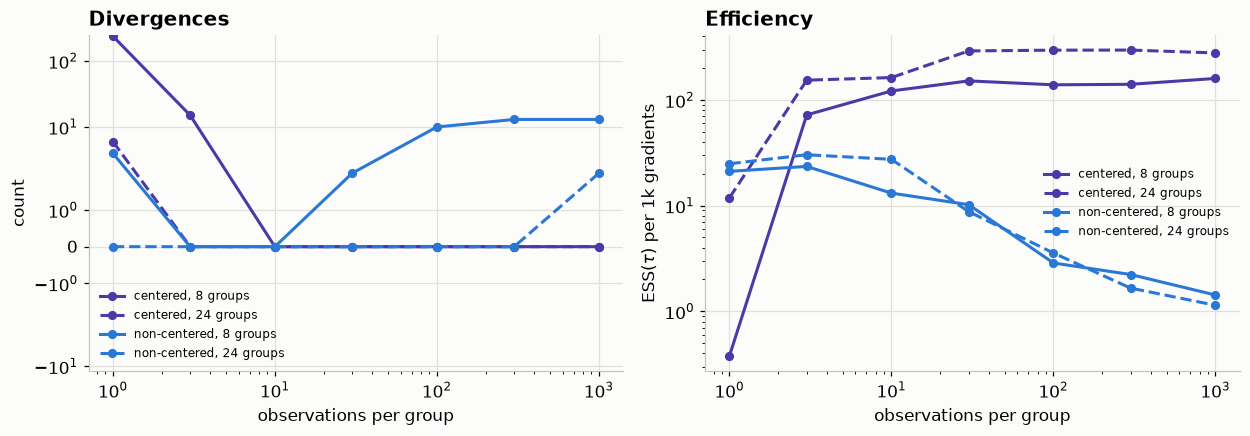

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.1))
for label, colour in [("centered", S.NAIVE), ("non-centered", S.PRIMARY)]:
    for n_groups, style in zip(GROUP_COUNTS, ["-", "--"]):
        sub = sweep[(sweep.param == label) & (sweep.groups == n_groups)]
        tag = f"{label}, {n_groups} groups"
        ax1.plot(sub["obs/group"], sub["divergences"], "o" + style, color=colour,
                 label=tag, ms=5)
        ax2.plot(sub["obs/group"], sub["ESS per 1k grads"], "o" + style,
                 color=colour, label=tag, ms=5)
ax1.set(title="Divergences", xlabel="observations per group", xscale="log",
        yscale="symlog", ylabel="count")
ax1.legend(fontsize=8)
ax2.set(title="Efficiency", xlabel="observations per group", xscale="log",
        yscale="log", ylabel=r"ESS($\tau$) per 1k gradients")
ax2.legend(fontsize=8)
fig.tight_layout()

Read the right-hand panel first, and note the **log** vertical axis. The two
curves cross almost immediately — non-centered wins only in the sparsest
column, at one observation per group — and then they separate by orders of
magnitude. By 1000 observations per group, centering is worth a **hundredfold
to two-hundredfold** difference in ESS per unit of work, depending on panel
size. The far end of this sweep is not a curiosity; it is where a lot of real
cognitive data sits.

Now the left panel, which is interesting for a different reason.

<details class="sbi-note">
<summary>📝 <b>The rule, stated properly</b></summary>

"Always non-center hierarchical models" is the single most widespread piece of
wrong advice in applied Bayesian work. The correct statement is: **non-center
the parameters whose groups are data-poor.** With enough data per group the
centered form is better behaved, because then the likelihood — not the prior —
is what shapes each group's posterior.

Which is why you want the choice to be **per parameter**.

</details>

<details class="sbi-key" open>
<summary>🔑 <b>More groups suppresses the divergences without fixing the efficiency</b></summary>

Compare the solid lines (8 groups) with the dashed ones (24). Divergences
largely **disappear** on the bigger panel: the centered fit at one observation
per group falls from 236 divergences to 6, and the non-centered fit's
complaints at the data-rich end (10, 13, 13) drop to (0, 0, 2).

That is not the geometry being repaired. It is exactly Betancourt's remark,
which you can now read off a figure rather than take on trust: **more groups
means more information about $\tau$, which trims off the extreme values of
$\tau$ where the pathology lives.**

The efficiency panel keeps the same shape and the same ordering throughout. So
a clean divergence count is *not* evidence that you chose the right
parameterization — it may only mean you had enough groups to hide the
consequences of choosing the wrong one. Judge by ESS per gradient, and let
divergences tell you about correctness rather than about cost.

</details>

### What that looks like in the geometry

The ESS curves say *that* the advantage reverses. This says *why*. Four fits —
both parameterizations, at weak and strong data — each plotted in the
coordinates its own sampler actually works in, against $\log\tau$, with
divergences overlaid.

The panel here is deliberately larger than the eight-schools dataset this
demonstration is traditionally built on. **The group count is itself a knob on
the geometry**: every group contributes one $\theta$ that has to pass through
the same neck, so a centered sampler on 32 groups is threading 32 coordinates
at once rather than eight. Measured on this panel, weak likelihood, centered:

| groups | divergences | ESS($\tau$) |
|---|---|---|
| 8 | 346 | 390 |
| 16 | 333 | 163 |
| 32 | 670 | 67 |
| 64 | 1038 | 11 |

The non-centered fit stays healthy across all of them. Eight groups is enough
to *see* the problem; more makes it unmissable.

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, tau, theta]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 3 seconds.


There were 670 divergences after tuning. Increase `target_accept` or reparameterize.


...

NUTS: [mu, tau, z]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


32 groups


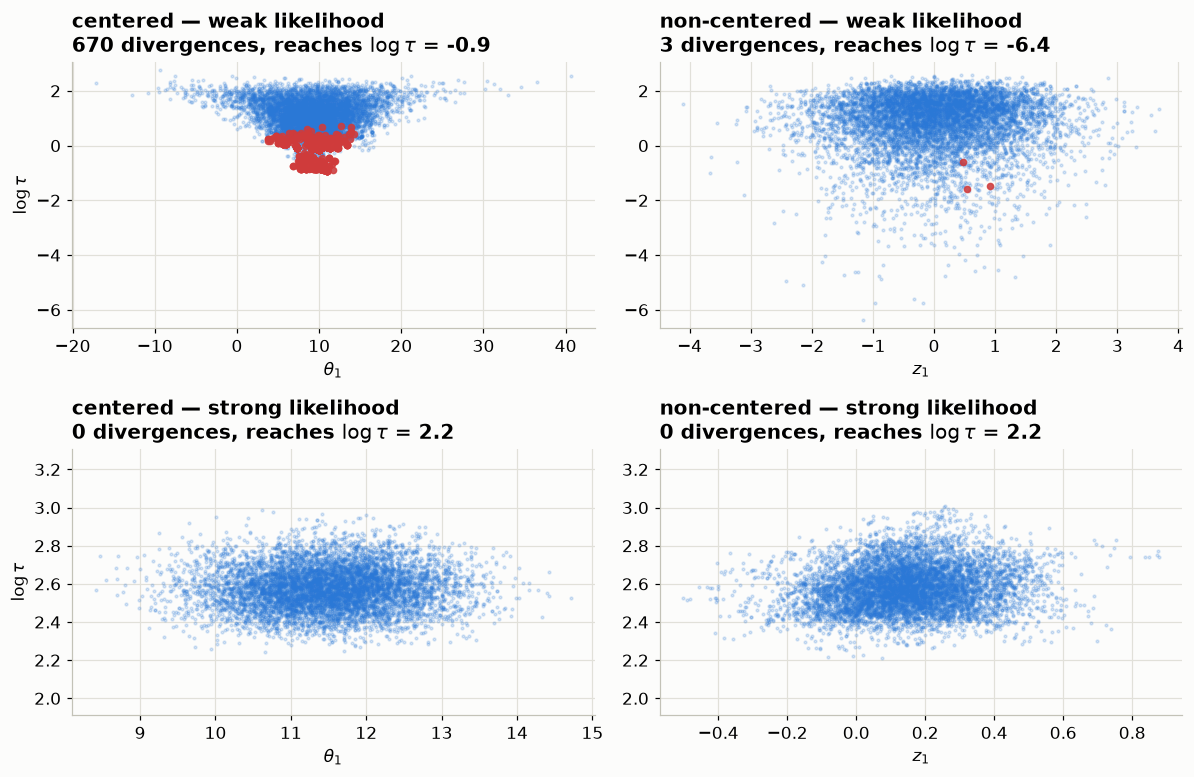

In [14]:
geom = F.geometry_experiment(seed=RANDOM_SEED)
print(f"{geom['n_groups']} groups")
F.fig_geometry_grid(geom)

In [15]:
print(f"{'parameterization':16s} {'se scale':>9s} {'divergences':>12s} "
      f"{'min log tau':>12s} {'ESS(tau)':>10s}")
for (scale, par), d in geom["results"].items():
    print(f"{par:16s} {scale:9g} {d['n_divergences']:12d} "
          f"{d['min_log_tau']:12.2f} {d['ess_tau']:10.1f}")

parameterization  se scale  divergences  min log tau   ESS(tau)
centered                 1          670        -0.92       67.2
non-centered             1            3        -6.38     3490.6
centered              0.05            0         2.24    18378.3
non-centered          0.05            0         2.21      195.6


Read the four panels as a 2×2, and note that **the two panels in each row
share a $\log\tau$ axis** — that is what makes the comparison honest.

**Top row (weak likelihood).** The centered chain simply *stops* around
$\log\tau \approx -0.9$, with hundreds of divergences piled against that floor.
The non-centered chain, on the same axis, carries on down past $-6$. The
centered sampler is not exploring the neck badly — it is not exploring it at
all, and it reports $\hat{R} \approx 1$ while failing. The ESS column is the
blunt version: **67 against 3491**, a fifty-fold difference from a change of
coordinates alone.

**Bottom row (strong likelihood).** Centered is now clean — zero divergences,
a round blob. Non-centered has developed a hard **diagonal ridge**: to hold
$\theta_g$ where the data wants it while $\tau$ grows, $z_g$ must shrink. That
is the inverted funnel, and it is why the advice reverses. Here neither fit
diverges, so the divergence count tells you nothing and the ESS column tells
you everything — **18378 against 196**, now favouring centered.

<details class="sbi-note">
<summary>📝 <b>And yet non-centered is still the sensible default</b></summary>

The inverted funnel is *suppressed by partial pooling itself* — the more
groups there are informing $\tau$, the more its bad end gets cut off.
Betancourt puts it sharply: **"the pathological behavior is the worst exactly
when the partial pooling is strongest."** So the reversal usually costs you
efficiency rather than correctness, which is why "non-center by default, and
reconsider when a group is data-rich" is reasonable advice.

</details>

<details class="sbi-warn" open>
<summary>⚠️ <b>Do not memorise the crossover point</b></summary>

The crossover moves with the number of groups, the group-scale prior, and how
much the groups actually differ — so "the crossover is between 1 and 3
observations per group" is a fact about *this* setup, not a constant. You saw
one of those dependencies directly: changing only the panel size moved the
divergence counts substantially.

What transfers is the *shape*: two curves that cross, and a rule for which
side you are on. Run the sweep on your own model rather than importing a
number from someone else's.

</details>

## 5. Per-parameter parameterization in HSSM

A real SSM has parameters of both kinds in the same model. Drift `v` is often
estimated from plenty of trials per participant; a boundary or non-decision
time may be far more weakly identified. HSSM lets you choose independently.

In [16]:
import hssm

data = hssm.load_data("cavanagh_theta")
print(data.head(3).to_string(index=False))
print("\nparticipants:", data["participant_id"].nunique(), " trials:", len(data))

 participant_id stim   rt  response     theta  dbs conf
              0   LL 1.21       1.0  0.656275    1   HC
              0   WL 1.63       1.0 -0.327889    1   LC
              0   WW 1.03       1.0 -0.480285    1   HC

participants: 14  trials: 3988


`noncentered` is not an HSSM argument — it passes straight through to
`bmb.Model`. It takes a bool **or a dict keyed by parameter**, and a
per-prior setting overrides the dict:

```
resolution order:  prior.noncentered  >  noncentered[param]  >  True
```

In [17]:
def build(noncentered):
    return hssm.HSSM(
        data=data,
        model="ddm",
        noncentered=noncentered,
        include=[
            {"name": "v", "formula": "v ~ 1 + (1|participant_id)"},
            {"name": "a", "formula": "a ~ 1 + (1|participant_id)"},
        ],
        p_outlier=0.05,          # explicit: this is the default, not "off"
        prior_settings="safe",
    )


mixed = build({"v": False, "a": True})

# The PyMC graph is materialised at construction — `model.pymc_model` is ready
# to inspect, and there is no `.build()` to call.
participant_nodes = sorted(n for n in mixed.pymc_model.named_vars
                           if "participant_id" in n)
print("participant-level nodes:")
for n in participant_nodes:
    mark = "  <- non-centered" if n.endswith("_offset") else ""
    print(f"    {n}{mark}")

Model initialized successfully.


participant-level nodes:
    a_1|participant_id
    a_1|participant_id_offset  <- non-centered
    a_1|participant_id_sigma
    v_1|participant_id
    v_1|participant_id_sigma


The `_offset` nodes are the structural fingerprint of the non-centered
parameterization: `u_g = z_g · σ`. `a` has one, `v` does not — exactly what we
asked for. You can read the parameterization off the graph without sampling
anything.

<details class="sbi-warn" open>
<summary>⚠️ <b>Two ways this bites</b></summary>

**Non-centering only works for `Normal` priors whose `sigma` is itself a
random variable.:** 

Anything else raises `NotImplementedError` when the model
is built — loud, at least.

**Check for disconnected nodes:** 

A `Normal` group prior with a nested `mu` hyperprior under
non-centering leaves `mu` as a **disconnected free variable** — sampled, but
influencing nothing. HSSM 0.4.0 ships detectors for this
(`check_user_priors_against_parameterization`, `find_disconnected_free_rvs`).
Always check `print(model)` / `model.graph()` after changing parameterization,
because term-prior keys differ between the two forms and a mismatched key is
**silently dropped**.

</details>

### Exercise

Build the same model with `noncentered=True` and with `noncentered=False`, and
confirm from the graph alone (no sampling) which nodes change. Then predict —
before running anything — which setting you would want for `v` in the Cavanagh
data, given its 3,988 trials spread over 14 participants.

<details>
<summary>Solution and reasoning</summary>

```python
for setting in [True, False]:
    m = build(setting)
    offs = sorted(n for n in m.pymc_model.named_vars if n.endswith("_offset"))
    print(setting, "->", offs)
```

With roughly 285 trials per participant, the drift rate is well identified
*within* each participant — the likelihood dominates, so **centered** is the
better choice for `v`. Parameters that are weakly constrained per participant,
or a group scale estimated from only 14 groups, are the ones that want
non-centering. This is the crossover from section 3, in a real model.

</details>

## 6. The capstone: a slope per participant

Section 1 gave every participant their own *drift*. Real designs ask for more
than that: drift usually **varies within a participant** with some
manipulation. So give every participant their own **slope** as well:

$$v_{gi} \;=\; \beta^{(g)}_0 \;+\; \beta^{(g)}_1 \cdot \text{difficulty}_i,
  \qquad
  \beta^{(g)}_0, \beta^{(g)}_1 \sim \text{Normal}(\mu_\beta, \tau_\beta)$$

Same brutal panel — trial counts from 5 to 600 — and difficulty varies
continuously from trial to trial.

A slope is *harder* than an intercept. It needs enough trials **and** enough
spread in the covariate. With five trials you have neither.

In [18]:
reg = F.regression_experiment(seed=RANDOM_SEED)

for name in ("intercept", "slope"):
    s = F.pooling_summary(reg[name])
    print(f"{name:10s} MAE  n<30: {s['no_pooling']['mae_low']:.3f} -> "
          f"{s['partial_pooling']['mae_low']:.3f}"
          f"   |  n>=30: {s['no_pooling']['mae_high']:.3f} -> "
          f"{s['partial_pooling']['mae_high']:.3f}"
          f"   |  {s['low_n_improvement_pct']:.0f}% better where thin")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [b0, b1]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu_b0, tau_b0, mu_b1, tau_b1, z0, z1]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


intercept  MAE  n<30: 0.354 -> 0.184   |  n>=30: 0.050 -> 0.047   |  48% better where thin
slope      MAE  n<30: 0.598 -> 0.229   |  n>=30: 0.100 -> 0.106   |  62% better where thin


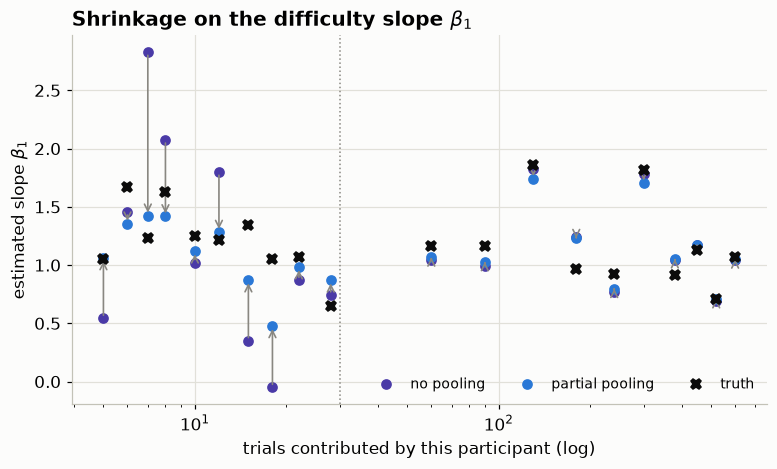

In [19]:
F.fig_shrinkage(reg["slope"], ylabel=r"estimated slope $\beta_1$",
                title=r"Shrinkage on the difficulty slope $\beta_1$")

Look at the left-hand side. Without pooling, a participant with a handful of
trials gets a slope of **2.9** where the truth is near 1.2, and another gets a
slope that is essentially **zero** — or negative — where the truth is 1.4.
Those are not estimates, they are noise with a credible interval attached.

Partial pooling drags them back toward the population slope, which is the
best available guess for someone who has not given you enough data to say
otherwise. On the right-hand side, where participants *have* spoken for
themselves, the two methods agree and pooling changes nothing.

<details class="sbi-note">
<summary>📝 <b>Why the slope gains more than the intercept</b></summary>

The improvement where trials are thin is around **48%** for the intercept and
around **62%** for the slope. A slope is the harder quantity — it needs the
covariate to have moved *within* that participant — so it is the first thing
to fall apart when data is scarce, and the thing pooling rescues most.

This is the practical argument for hierarchy in cognitive modelling. It is
rarely "we want a population estimate". It is "we want per-participant
estimates, and some of our participants are thin."

</details>

<details class="sbi-warn" open>
<summary>⚠️ <b>What pooling is not</b></summary>

It does not manufacture information. The rescued slopes are **closer** to the
truth, not correct — look at how far the five-trial participants still sit
from their black crosses. Pooling buys you a defensible estimate where you
would otherwise have had a wild one; it does not buy you the experiment you
failed to run.

</details>

### Exercise

The panel fixes `a`, `z` and `t` so the comparison is about `v` alone. Give
the boundary `a` a per-participant random effect too, and predict — before
running it — whether pooling helps `a` more or less than it helped the slope.

<details>
<summary>What to expect, and why</summary>

Less pronounced in one sense and more in another. `a` is identified through
the *speed–accuracy relationship* rather than through trial count alone, so
adding trials helps it more slowly than it helps `v` — meaning even the
data-rich participants stay somewhat prior-dependent, and pooling keeps
earning its keep further to the right of the plot.

That is the same observation as the per-parameter parameterization argument
in section 5: **different parameters are informed by different amounts of the
same data.** If you find `a` still shrinking hard at 600 trials, that is your
evidence that `a` wants a non-centered parameterization while `v` does not.

</details>

### References

- Neal, R. (2003). Slice sampling. *Annals of Statistics* 31(3), 705–767.
- Papaspiliopoulos, Roberts & Sköld (2007). A general framework for the
  parametrization of hierarchical models. *Statistical Science* 22(1), 59–73.
- Betancourt & Girolami (2013). Hamiltonian Monte Carlo for hierarchical
  models. [arXiv:1312.0906](https://arxiv.org/abs/1312.0906)
- Betancourt (2017). Diagnosing biased inference with divergences.
- Gorinova, Moore & Hoffman (2020). Automatic reparameterisation of
  probabilistic programs. *ICML*.